# 🔢 Praktikum 02 – Tokenisierung · Embeddings · Neuronale Grundlagen
**Applied Generative AI – NLP | Sommersemester 2026**

> ⏱️ **Gesamtdauer: ~90 Minuten**  
> 🎯 **Lernziele:** Tokenizer verstehen und vergleichen · Token-Counts analysieren · Word2Vec-Embeddings laden und visualisieren · semantische Analogien testen · einfaches MLP trainieren

---
### Pakete installieren (optional)
```bash
uv add tiktoken transformers gensim matplotlib scikit-learn torch torchvision umap-learn
```


In [1]:
import importlib
import os
import shutil
import subprocess
import sys
from importlib.util import find_spec

import certifi

IN_COLAB = "google.colab" in sys.modules
AUTO_INSTALL_MISSING = True

REQUIRED = {
    "tiktoken": {"version": "0.12.0", "install_name": "tiktoken", "import_name": "tiktoken"},
    "transformers": {"version": "5.6.0", "install_name": "transformers", "import_name": "transformers"},
    "gensim": {"version": "4.4.0", "install_name": "gensim", "import_name": "gensim"},
    "matplotlib": {"version": "3.10.8", "install_name": "matplotlib", "import_name": "matplotlib"},
    "sklearn": {"version": "1.8.0", "install_name": "scikit-learn", "import_name": "sklearn"},
    "torch": {"version": "2.10.0", "install_name": "torch", "import_name": "torch"},
    "torchvision": {"version": "0.25.0", "install_name": "torchvision", "import_name": "torchvision"},
    "numpy": {"version": "2.4.4", "install_name": "numpy", "import_name": "numpy"},
}


def install_specs(specs, reinstall=False):
    if shutil.which("uv") is None:
        raise RuntimeError("uv ist nicht installiert. Installiere uv und führe die Setup-Zelle erneut aus.")

    command = ["uv", "pip", "install", "--python", sys.executable]
    in_venv = sys.prefix != getattr(sys, "base_prefix", sys.prefix) or bool(os.environ.get("VIRTUAL_ENV"))
    if not in_venv:
        command.append("--system")
    if reinstall:
        command.append("--reinstall")

    cmd = command + list(specs)
    print("$", " ".join(cmd))
    subprocess.check_call(cmd)


def collect_issues():
    issues = []
    for package_name, cfg in REQUIRED.items():
        import_name = cfg["import_name"]
        required_version = cfg["version"]
        if find_spec(import_name) is None:
            issues.append((package_name, f"{package_name} fehlt"))
            continue
        try:
            module = importlib.import_module(import_name)
            current_version = getattr(module, "__version__", None)
        except Exception as exc:
            issues.append((package_name, f"{package_name} kann nicht importiert werden: {exc}"))
            continue
        if current_version != required_version:
            issues.append((package_name, f"{package_name} hat Version {current_version}, erwartet wird {required_version}"))
    return issues


issues = collect_issues()
if issues:
    print("Setup-Probleme erkannt:")
    for _, message in issues:
        print(" -", message)
    if not AUTO_INSTALL_MISSING:
        raise RuntimeError("AUTO_INSTALL_MISSING ist False, aber Pakete fehlen oder sind defekt.")
    specs = [f"{REQUIRED[name]['install_name']}=={REQUIRED[name]['version']}" for name, _ in issues]
    install_specs(specs, reinstall=True)
    importlib.invalidate_caches()

remaining_issues = collect_issues()
if remaining_issues:
    details = "; ".join(message for _, message in remaining_issues)
    raise RuntimeError(f"Diese Pakete sind weiterhin nicht nutzbar: {details}")

ca_bundle = certifi.where()
os.environ["SSL_CERT_FILE"] = ca_bundle
os.environ["REQUESTS_CA_BUNDLE"] = ca_bundle

for package_name, cfg in REQUIRED.items():
    module = importlib.import_module(cfg["import_name"])
    print(f"  ✅  {package_name:<12} {getattr(module, '__version__', 'unknown')}")

print("CA bundle:", ca_bundle)
print("Runtime:", "Google Colab" if IN_COLAB else "Lokal/Jupyter")


/Users/joschkakersting/Nextcloud/vl/Folien/Praktikum/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  ✅  tiktoken     0.12.0
  ✅  transformers 5.6.0
  ✅  gensim       4.4.0
  ✅  matplotlib   3.10.8
  ✅  sklearn      1.8.0
  ✅  torch        2.10.0
  ✅  torchvision  0.25.0
  ✅  numpy        2.4.4
CA bundle: /Users/joschkakersting/Nextcloud/vl/Folien/Praktikum/.venv/lib/python3.13/site-packages/certifi/cacert.pem
Runtime: Lokal/Jupyter


## Teil 1 – Tokenisierung ⏱️ ~30 min

### 1.1 – tiktoken (OpenAI, BPE-nah) vs. Hugging Face Tokenizer (WordPiece)

Tokenizer zerlegen rohen Text in *Tokens* — die eigentliche Inputeinheit eines LLMs.  
Je nach Modell kommen unterschiedliche Verfahren zum Einsatz (z. B. BPE, WordPiece, SentencePiece).

In [2]:
import tiktoken
from transformers import AutoTokenizer

# OpenAI tiktoken (GPT-4)
enc_gpt4 = tiktoken.get_encoding("cl100k_base")

# HuggingFace – BERT-Tokenizer (WordPiece)
hf_tok = AutoTokenizer.from_pretrained("bert-base-uncased")

texts = {
    "DE Einfach"   : "Das neuronale Netz lernt Muster aus Daten.",
    "EN Einfach"   : "The neural network learns patterns from data.",
    "DE Fachbegriff": "Transformer-Architektur mit Multi-Head Self-Attention.",
    "EN Fachbegriff": "Transformer architecture with multi-head self-attention.",
    "Code"         : "def forward(self, x): return self.fc(x)",
    "Emoji"        : "KI ist super 🤖🚀✨ und macht Spaß!",
    "Arabisch"     : "الذكاء الاصطناعي يغير العالم",
}

print(f"{'Text':<35} {'GPT4-Tokens':>11} {'BERT-Tokens':>11}")
print("─" * 60)
for label, text in texts.items():
    gpt4_n  = len(enc_gpt4.encode(text))
    bert_n  = len(hf_tok.encode(text, add_special_tokens=False))
    print(f"  {label:<33} {gpt4_n:>11} {bert_n:>11}")


Text                                GPT4-Tokens BERT-Tokens
────────────────────────────────────────────────────────────
  DE Einfach                                 11          14
  EN Einfach                                  8           8
  DE Fachbegriff                             14          15
  EN Fachbegriff                              9          11
  Code                                       11          15
  Emoji                                      16          10
  Arabisch                                   19          25


### 1.2 – BPE visuell: Wie sieht ein Token aus?

In [3]:
example = "Transformer-Architektur und Backpropagation"
tokens_gpt4 = enc_gpt4.encode(example)
tokens_bert  = hf_tok.tokenize(example)

print("Originaltext :", example)
print()
print("GPT-4 (cl100k) Token-IDs :", tokens_gpt4)
print("GPT-4 (cl100k) Decoded    :", [enc_gpt4.decode([t]) for t in tokens_gpt4])
print()
print("BERT Subwords             :", tokens_bert)
print()
print(f"GPT-4: {len(tokens_gpt4)} Tokens | BERT: {len(tokens_bert)} Tokens")


Originaltext : Transformer-Architektur und Backpropagation

GPT-4 (cl100k) Token-IDs : [47458, 6830, 50166, 635, 5964, 324, 2073, 6984, 2741, 28236]
GPT-4 (cl100k) Decoded    : ['Transformer', '-A', 'rch', 'ite', 'kt', 'ur', ' und', ' Back', 'prop', 'agation']

BERT Subwords             : ['transform', '##er', '-', 'arch', '##ite', '##kt', '##ur', 'und', 'back', '##pro', '##pa', '##gation']

GPT-4: 10 Tokens | BERT: 12 Tokens


### 1.3 – Aufgabe: Context-Window und Kosten

> ❓ **Aufgabe:** Berechne, wie viele Tokens ein typischer 2-seitiger Bericht (ca. 500 Wörter) hat
> und was das bei einer API kostet, die 0,002 € / 1 000 Tokens berechnet.

In [4]:
report_text = """
Large Language Models (LLMs) haben in den letzten Jahren die Verarbeitung natürlicher Sprache
revolutioniert. Modelle wie GPT-4, Claude und Gemini können Text generieren, zusammenfassen,
übersetzen und komplexe Fragen beantworten. Der Schlüssel liegt in der Transformer-Architektur
und dem Training auf riesigen Textmengen. Dabei entstehen emergente Fähigkeiten, also
Kompetenzen, die bei kleinen Modellen nicht vorhanden waren und erst durch Skalierung auftreten.
Gleichzeitig stellen Halluzinationen – also confident formulierte Falschaussagen – ein
strukturelles Problem dar, das durch RAG oder RLHF mitigiert werden kann.
""" * 5   # × 5 ≈ 500-Wort-Text

n_words = len(report_text.split())
n_tokens = len(enc_gpt4.encode(report_text))
cost_euro = n_tokens / 1000 * 0.002

print(f"Tokens         : {n_tokens}")
print(f"Wörter (approx): {n_words}")
print(f"Tok/Wort-Ratio : {n_tokens / n_words:.2f}")
print(f"Kosten         : {cost_euro:.5f} €")

# Saubere lineare Hochrechnung über den Token-pro-Wort-Faktor.
report_words = 5000
estimated_tokens = (n_tokens / n_words) * report_words
estimated_cost = estimated_tokens / 1000 * 0.002
print()
print("→ Ein Standard-Geschäftsbericht (10 Seiten, 5 000 Wörter) kostet:")
print(f"  ≈ {estimated_cost:.3f} €")


Tokens         : 801
Wörter (approx): 400
Tok/Wort-Ratio : 2.00
Kosten         : 0.00160 €

→ Ein Standard-Geschäftsbericht (10 Seiten, 5 000 Wörter) kostet:
  ≈ 0.020 €


## Teil 2 – Word Embeddings & semantische Analogien ⏱️ ~25 min

### 2.1 – GloVe-Embeddings laden (via gensim)

> ℹ️ Beim ersten Ausführen wird das Modell heruntergeladen.  
> In diesem Notebook nutzen wir `glove-wiki-gigaword-100` (ca. 130 MB).

In [5]:
import gensim.downloader as api
import time

print("Lade glove-wiki-gigaword-100 (ca. 170 MB) ...")
print("  (Dies kann je nach Verbindung 1-5 Minuten dauern.)")
t0 = time.time()
wv = api.load("glove-wiki-gigaword-100")
elapsed = time.time() - t0
print(f"Geladen: {len(wv.key_to_index):,} Woerter, {wv.vector_size}d Vektoren in {elapsed:.1f}s")

Lade glove-wiki-gigaword-100 (ca. 170 MB) ...
  (Dies kann je nach Verbindung 1-5 Minuten dauern.)
Geladen: 400,000 Woerter, 100d Vektoren in 14.8s


### 2.2 – Semantische Analogien: König - Mann + Frau = ?

In [6]:
print("Semantische Analogien (most_similar_cosmul):")
print("=" * 60)

analogies = [
    ("king",    "man",     "woman",   "→ Erwartung: queen"),
    ("paris",   "france",  "germany", "→ Erwartung: berlin"),
    ("walked",  "walking", "running", "→ Erwartung: ran"),
    ("big",     "bigger",  "small",   "→ Erwartung: smaller"),
    ("doctor",  "man",     "woman",   "→ Genderbias?"),
]

for pos1, neg1, pos2, hint in analogies:
    try:
        result = wv.most_similar_cosmul(positive=[pos1, pos2], negative=[neg1], topn=3)
        top3 = ", ".join([f"{w}({s:.2f})" for w, s in result])
        print(f"  {pos1} - {neg1} + {pos2:<10} → {top3}  {hint}")
    except KeyError as e:
        print(f"  Nicht im Vokabular: {e}")


Semantische Analogien (most_similar_cosmul):
  king - man + woman      → queen(0.90), monarch(0.85), throne(0.84)  → Erwartung: queen
  paris - france + germany    → berlin(0.97), frankfurt(0.92), vienna(0.90)  → Erwartung: berlin
  walked - walking + running    → ran(0.94), run(0.90), went(0.89)  → Erwartung: ran
  big - bigger + small      → large(1.00), known(0.96), well(0.96)  → Erwartung: smaller
  doctor - man + woman      → nurse(0.97), physician(0.93), dentist(0.92)  → Genderbias?


### 2.3 – Kosinus-Ähnlichkeit zwischen Konzepten

In [7]:
pairs = [
    ("cat",   "dog"),
    ("cat",   "car"),
    ("king",  "queen"),
    ("happy", "sad"),
    ("neural", "network"),
    ("france","germany"),
]

print(f"{'Wort 1':<12} {'Wort 2':<12} {'Ähnlichkeit':>12}")
print("─" * 38)
for w1, w2 in pairs:
    sim = wv.similarity(w1, w2)
    bar = "█" * int(sim * 20)
    print(f"  {w1:<10} {w2:<12} {sim:>8.3f}  {bar}")


Wort 1       Wort 2        Ähnlichkeit
──────────────────────────────────────
  cat        dog             0.880  █████████████████
  cat        car             0.311  ██████
  king       queen           0.751  ███████████████
  happy      sad             0.680  █████████████
  neural     network         0.340  ██████
  france     germany         0.729  ██████████████


### 2.4 – t-SNE Visualisierung von Wort-Clustern

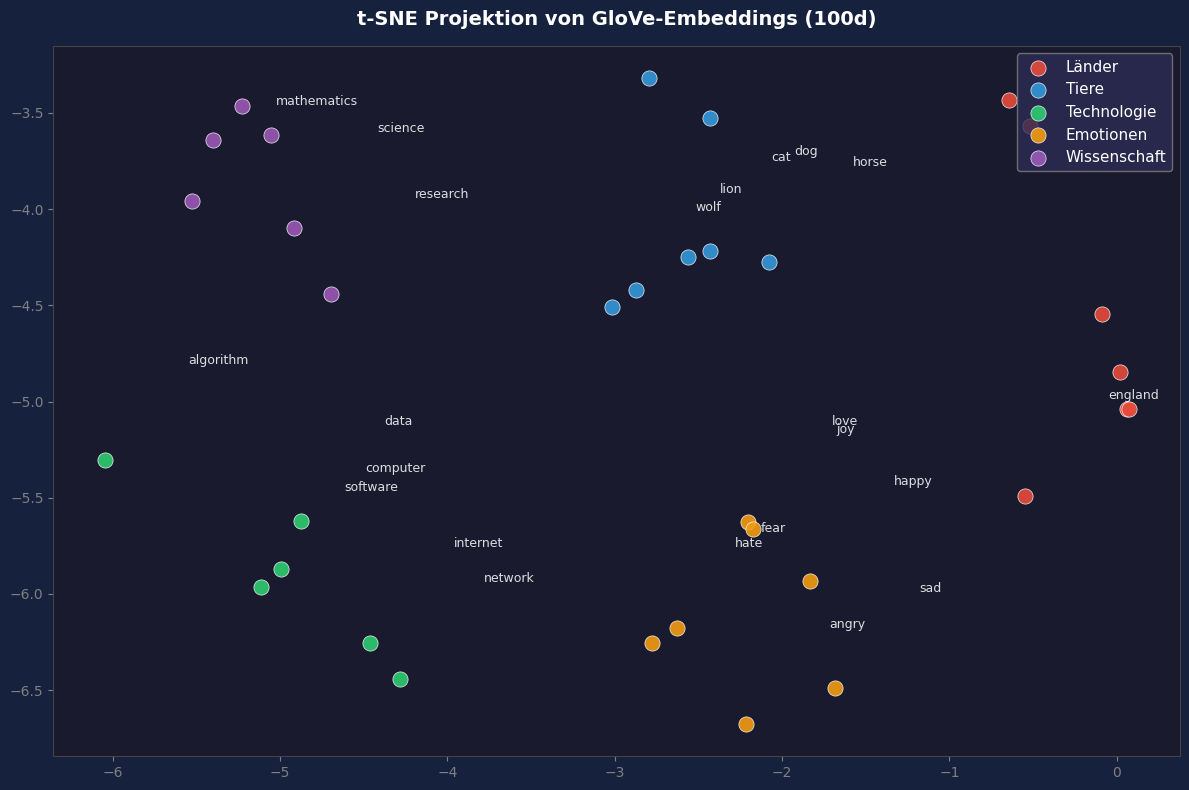

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Wörter aus verschiedenen semantischen Feldern
word_groups = {
    "Länder"       : ["germany", "france", "italy", "spain", "england", "japan", "china"],
    "Tiere"        : ["dog", "cat", "horse", "bird", "fish", "wolf", "lion"],
    "Technologie"  : ["computer", "internet", "software", "network", "algorithm", "data"],
    "Emotionen"    : ["happy", "sad", "angry", "fear", "love", "joy", "hate"],
    "Wissenschaft" : ["physics", "chemistry", "biology", "mathematics", "science", "research"],
}

colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]
words, vecs, color_list, labels = [], [], [], []

for (group, ws), color in zip(word_groups.items(), colors):
    for w in ws:
        if w in wv:
            words.append(w)
            vecs.append(wv[w])
            color_list.append(color)
            labels.append(group)

if len(vecs) < 3:
    raise ValueError("Zu wenige Wörter für t-SNE gefunden. Bitte Wortliste oder Embedding-Vokabular prüfen.")

vecs_np = np.array(vecs)
max_perplexity = max(2, min(20, len(vecs) - 1))

# t-SNE mit dynamischer Perplexity (robust für kleinere Stichproben)
try:
    tsne = TSNE(n_components=2, perplexity=max_perplexity, random_state=42, max_iter=1000)
except TypeError:
    tsne = TSNE(n_components=2, perplexity=max_perplexity, random_state=42, n_iter=1000)
reduced = tsne.fit_transform(vecs_np)

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor("#1a1a2e")
fig.patch.set_facecolor("#16213e")

for group, color in zip(word_groups.keys(), colors):
    mask = [l == group for l in labels]
    xs   = reduced[mask, 0]
    ys   = reduced[mask, 1]
    ax.scatter(xs, ys, c=color, s=120, label=group, alpha=0.9, edgecolors="white", linewidths=0.5)

for i, w in enumerate(words):
    ax.annotate(w, (reduced[i, 0]+0.5, reduced[i, 1]+0.5),
                fontsize=9, color="white", alpha=0.85)

ax.legend(loc="upper right", facecolor="#2c2c54", edgecolor="gray",
          labelcolor="white", fontsize=11)
ax.set_title("t-SNE Projektion von GloVe-Embeddings (100d)", 
             color="white", fontsize=14, fontweight="bold", pad=15)
ax.tick_params(colors="gray")
for spine in ax.spines.values():
    spine.set_edgecolor("#444")

plt.tight_layout()
plt.savefig("embedding_tsne_dark.png", dpi=140, bbox_inches="tight")
plt.show()

## Teil 3 – Einfaches MLP auf MNIST ⏱️ ~30 min

### 3.1 – Das Neuron und das Netz

Ein MLP (Multi-Layer Perceptron) besteht aus Schichten von Neuronen.  
Jede Schicht berechnet: **y = σ(Wx + b)**  
Wir trainieren ein 2-Layer-MLP auf dem MNIST-Datensatz (handgeschriebene Ziffern).

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Daten laden
transform = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((0.1307,), (0.3081,))])
train_ds = datasets.MNIST("./data", train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False)

print(f"Train: {len(train_ds):,} Bilder  |  Test: {len(test_ds):,} Bilder")
print(f"Input-Shape: 28×28 = {28*28} Pixel")


Device: cpu
Train: 60,000 Bilder  |  Test: 10,000 Bilder
Input-Shape: 28×28 = 784 Pixel


### 3.2 – Trainingsbeispiele anzeigen

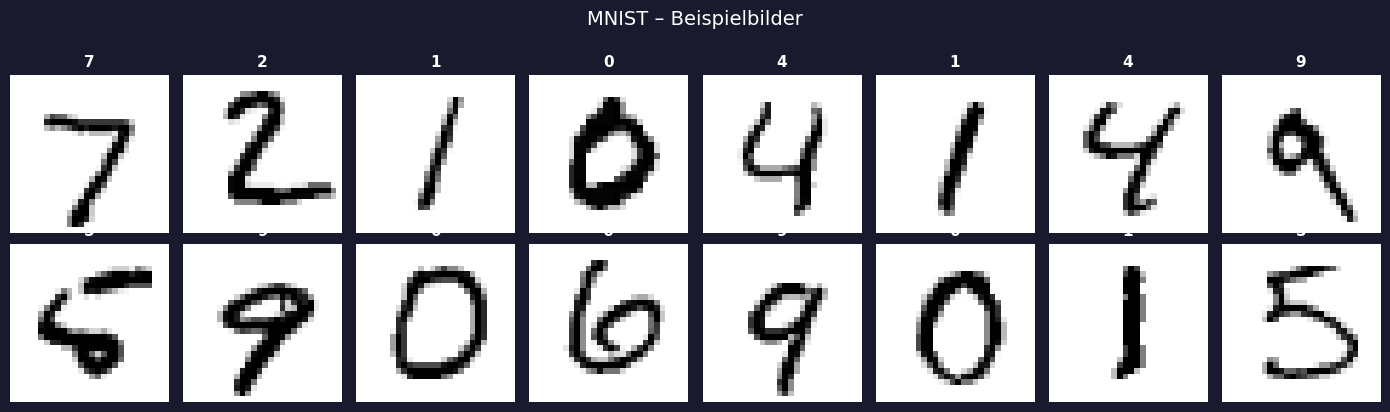

In [10]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.patch.set_facecolor("#1a1a2e")
imgs, lbls = next(iter(test_loader))

for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i].squeeze(), cmap="gray_r")
    ax.set_title(str(lbls[i].item()), color="white", fontsize=11, fontweight="bold")
    ax.axis("off")

plt.suptitle("MNIST – Beispielbilder", color="white", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("mnist_samples.png", dpi=120, bbox_inches="tight")
plt.show()


### 3.3 – MLP-Architektur definieren

```
Input (784) → Linear(256) → ReLU → Dropout → Linear(128) → ReLU → Dropout → Linear(10)
```

Hinweis: Die letzte Schicht liefert Logits; `nn.CrossEntropyLoss` enthält intern bereits Softmax.

In [11]:
class MLP(nn.Module):
    def __init__(self, hidden1=256, hidden2=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, hidden1),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden2, 10)
        )

    def forward(self, x):
        return self.net(x)

model = MLP().to(device)
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\nParameter gesamt : {total_params:,}")
print(f"Trainierbar      : {train_params:,}")
print(f"Speicher (FP32)  : {total_params * 4 / 1024**2:.2f} MB")


MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=128, out_features=10, bias=True)
  )
)

Parameter gesamt : 235,146
Trainierbar      : 235,146
Speicher (FP32)  : 0.90 MB


### 3.4 – Training und Evaluation

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

def evaluate(loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total   += y.size(0)
    return correct / total

EPOCHS = 3
train_losses, test_accs = [], []

print(f"{'Epoche':<8} {'Train-Loss':>12} {'Test-Acc':>10} {'LR':>10}")
print("─" * 44)

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    acc = evaluate(test_loader)
    lr  = scheduler.get_last_lr()[0]
    scheduler.step()

    train_losses.append(avg_loss)
    test_accs.append(acc)

    bar = "█" * int(acc * 30)
    print(f"  {epoch:<6} {avg_loss:>12.4f} {acc*100:>9.2f}%  {lr:.1e}  {bar}")

print(f"\n🎯 Finale Test-Accuracy: {test_accs[-1]*100:.2f}%")


Epoche     Train-Loss   Test-Acc         LR
────────────────────────────────────────────
  1            0.3880     95.13%  1.0e-03  ████████████████████████████
  2            0.1573     96.65%  1.0e-03  ████████████████████████████
  3            0.1155     97.16%  1.0e-03  █████████████████████████████

🎯 Finale Test-Accuracy: 97.16%


### 3.5 – Lernkurven visualisieren

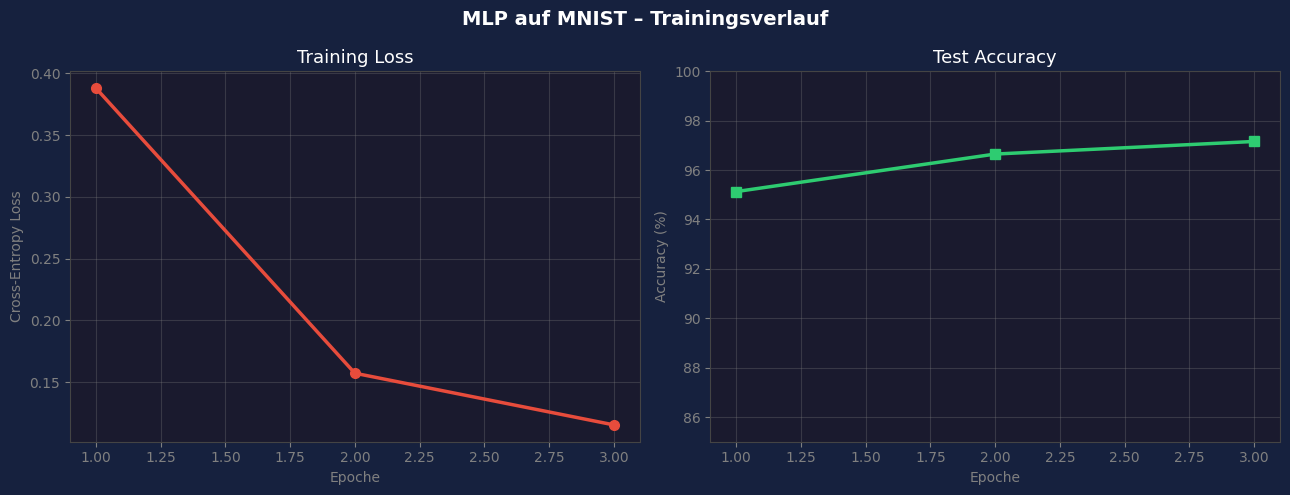

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#16213e")
for ax in [ax1, ax2]:
    ax.set_facecolor("#1a1a2e")

epochs_x = range(1, EPOCHS + 1)

ax1.plot(epochs_x, train_losses, color="#e74c3c", linewidth=2.5, marker="o", markersize=7)
ax1.set_title("Training Loss", color="white", fontsize=13)
ax1.set_xlabel("Epoche", color="gray")
ax1.set_ylabel("Cross-Entropy Loss", color="gray")
ax1.tick_params(colors="gray")
ax1.grid(alpha=0.3, color="gray")
for s in ax1.spines.values(): s.set_edgecolor("#444")

ax2.plot(epochs_x, [a * 100 for a in test_accs], color="#2ecc71", linewidth=2.5, marker="s", markersize=7)
ax2.set_title("Test Accuracy", color="white", fontsize=13)
ax2.set_xlabel("Epoche", color="gray")
ax2.set_ylabel("Accuracy (%)", color="gray")
ax2.set_ylim(85, 100)
ax2.tick_params(colors="gray")
ax2.grid(alpha=0.3, color="gray")
for s in ax2.spines.values(): s.set_edgecolor("#444")

plt.suptitle("MLP auf MNIST – Trainingsverlauf", color="white", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("mlp_training.png", dpi=150, bbox_inches="tight")
plt.show()


## ✅ Zusammenfassung & Aufgaben

| Konzept | Umsetzung |
|---------|-----------|
| BPE-/WordPiece-Tokenisierung | tiktoken & HF-Tokenizer verglichen |
| Token-Kosten | Pro-Token-Berechnung für APIs |
| Embeddings | GloVe 100d über gensim |
| Semantische Analogien | König - Mann + Frau |
| t-SNE | 2D-Visualisierung von Wort-Clustern |
| Neuron & MLP | MLP mit zwei Hidden Layers auf MNIST |
| Backpropagation | Adam-Optimizer mit LR-Scheduler |

### 🧩 Aufgaben zur Vertiefung

1. **Tokenizer-Vergleich:** Welche Sprache wird von GPT-4's Tokenizer am ineffizientesten tokenisiert? Teste Arabisch, Chinesisch und Russisch.
2. **Embedding-Bias:** Suche 3 Beispiele für Bias in Embedding-Analogien.
3. **MLP verbessern:** Füge eine dritte Hidden-Layer hinzu. Verbessert sich die Accuracy?
4. **UMAP statt t-SNE:** Installiere `umap-learn` und erstelle eine UMAP-Visualisierung der Embeddings.
